In [2]:
# import IT_PI is a module
import IT_PI
from scipy.special import erf
import numpy as np
from numpy.linalg import inv, matrix_rank
from pprint import pprint

In [2]:
def velocity_profile(y, nu, U, t):
    return U * (1 - erf(y / (2 * np.sqrt(nu * t))))

# Generate synthetic dataset
y_vals = np.linspace(0, 1, 20)
t_vals = np.linspace(5, 10, 20)
U = np.random.uniform(0.5, 1.0, 5)
nu = np.random.uniform(1e-3, 1e-2, 5)
u_array = []
params = []

for u0, n0 in zip(U, nu):
    for y in y_vals:
        for t in t_vals:
            u_array.append(velocity_profile(y, n0, u0, t))
            params.append([u0, y, t, n0])
u_array = np.array(u_array).reshape(-1, 1)
params = np.array(params)

In [3]:
# Define inputs and outputs
Y = u_array / params[:, 0].reshape(-1, 1)  # Output Pi_o = u/U
X = params                                 # Dimensional input list q
variables = ['U', 'y', 't', '\\nu']        # Variable names
D_in = np.matrix('1 1 0 2; -1 0 1 -1')     # Dimension matrix
num_input = 1

print("Rank of D_in:", matrix_rank(D_in))
print("D_in matrix:\n", D_in)
num_basis    = D_in.shape[1] - matrix_rank(D_in)
basis_matrices = IT_PI.calc_basis(D_in, num_basis)
print("Basis vectors:")
pprint(basis_matrices)


Rank of D_in: 2
D_in matrix:
 [[ 1  1  0  2]
 [-1  0  1 -1]]
Basis vectors:
matrix([[-1.,  1., -1.,  0.],
        [ 1.,  1.,  0., -1.]])


In [12]:
# Run IT_PI
results = IT_PI.main(
    X,
    Y,
    basis_matrices,
    num_input=1,
    estimator="kraskov",
    estimator_params={"k": 5},
    seed=42
)

------------------------------------------------------------
num of parameters: 2

Using estimator: 'kraskov' with hyperparameters: {'k': 5}

(150_w,300)-aCMA-ES (mu_w=78.0,w_1=3%) in dimension 2 (seed=42, Tue Mar 17 21:53:30 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1    300 -3.334806051521885e+00 1.0e+00 7.94e-01  6e-01  7e-01 0:00.6
    2    600 -3.300935855062012e+00 1.9e+00 9.34e-01  4e-01  6e-01 0:01.4
    3    900 -3.633250043595595e+00 3.9e+00 9.53e-01  2e-01  3e-01 0:02.3
    7   2100 -4.184351139051758e+00 1.6e+01 1.85e+00  1e-01  1e-01 0:05.9
   12   3600 -4.217069199342229e+00 7.7e+01 3.46e+00  3e-02  3e-02 0:10.2
   19   5700 -4.218293636203033e+00 1.2e+02 4.23e+00  1e-03  1e-03 0:16.0
   27   8100 -4.218582622042548e+00 9.0e+01 6.37e+00  6e-05  6e-05 0:22.2
   36  10800 -4.218656644612260e+00 5.8e+01 1.27e+01  2e-06  2e-06 0:29.3
   44  13200 -4.218656644612260e+00 3.6e+01 2.25e+01  6e-07  7e-07 0:35.6
termination on {'tolfunhist': 

Optimal_pi_lab[0] = $\frac{y^{1.0}}{t^{0.5} \cdot \nu^{0.5}}$


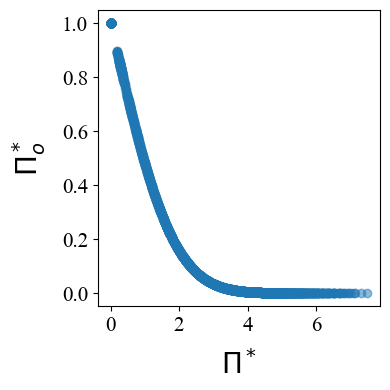

x_labels: ['${\\Pi}^*$']


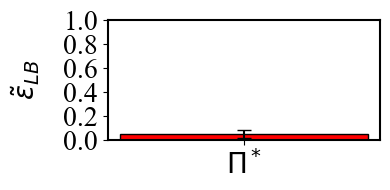

In [5]:
# Display results
# Disable LaTeX rendering (avoids requiring a system 'latex' binary)
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

coef_pi_list     = results["input_coef"]
variables        = ['U','y', 't','\\nu'];                       #Define variable name
optimal_pi_lab   = IT_PI.create_labels(np.array(coef_pi_list).reshape(-1, len(variables)), variables)
for j, label in enumerate(optimal_pi_lab):
    print(f'Optimal_pi_lab[{j}] = {label}')
input_PI = results["input_PI"]
output_PI = results["output_PI"]
epsilon  = results["irreducible_error"]
uq       = results["uncertainty"]

IT_PI.plot_scatter(input_PI,output_PI)
IT_PI.plot_error_bars(input_PI, epsilon,uq)

In [6]:
# ------------------------------------------------------------
# Test (with a length scale L): u(x, y, z) = sin(x/L) cos((y z)/L^2)
# Goal: recover two main variables: (x/L) and (y z / L^2)
# (Written in the same style as the velocity_profile example.)
# ------------------------------------------------------------

import numpy as np
from numpy.linalg import matrix_rank

def u_xyz(x, y, z, L):
    # Make trig arguments dimensionless
    return np.sin(x / L) * np.cos((y * z) / (L**2))

# Generate synthetic dataset
x_vals = np.linspace(0.01, 2*np.pi + 0.01, 25)
y_vals = np.linspace(0.01, 2*np.pi + 0.01, 25)
z_vals = np.linspace(0.01, 2*np.pi + 0.01, 25)
L0 = 1.0

u_array = []
params = []

for x0 in x_vals:
    for y0 in y_vals:
        for z0 in z_vals:
            u_array.append(u_xyz(x0, y0, z0, L0))
            params.append([x0, y0, z0, L0])

u_array = np.array(u_array).reshape(-1, 1)
params = np.array(params)

# Define inputs and outputs
Y_test = u_array
X_test = params  # [x, y, z, L]
variables = ["x", "y", "z", "L"]

# Fake dimensions: treat x,y,z,L as having the same length dimension.
# D_in has 1 basic dimension (L), so it is 1 x 4.
D_in = np.matrix('1 1 1 1')
num_basis = D_in.shape[1] - matrix_rank(D_in)
basis_matrices = IT_PI.calc_basis(D_in, num_basis)

results_test = IT_PI.main(
    X_test,
    Y_test,
    basis_matrices,
    num_input=2,
    estimator="kraskov",
    estimator_params={"k": 5},
    seed=42,
)

print("\nOptimized exponent vectors (for variables [x, y, z, L]):")
for j, coef in enumerate(results_test["input_coef"], start=1):
    coef = np.asarray(coef).reshape(-1)
    terms = " * ".join([f"{name}^{c: .3f}" for name, c in zip(variables, coef)])
    print(f"  Pi{j}: {terms}")

# Simple interpretability: correlate each learned Pi with (x/L) and with (y*z/L^2)
Pi = results_test["input_PI"]  # shape (N, 2)
x_over_L = params[:, 0] / params[:, 3]
yz_over_L2 = (params[:, 1] * params[:, 2]) / (params[:, 3] ** 2)

def corr(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    a = a - a.mean()
    b = b - b.mean()
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    return float(a.dot(b) / denom) if denom > 0 else np.nan

for j in range(Pi.shape[1]):
    print(
        f"corr(Pi{j+1}, x/L)={corr(Pi[:, j], x_over_L): .3f}, "
        f"corr(Pi{j+1}, y*z/L^2)={corr(Pi[:, j], yz_over_L2): .3f}"
    )


------------------------------------------------------------
num of parameters: 6

Using estimator: 'kraskov' with hyperparameters: {'k': 5}

(150_w,300)-aCMA-ES (mu_w=78.0,w_1=3%) in dimension 6 (seed=42, Thu Mar 19 16:38:51 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1    300 -1.021963462406889e+00 1.0e+00 5.25e-01  4e-01  7e-01 0:22.1
    2    600 -1.054138644169349e+00 2.1e+00 5.26e-01  3e-01  7e-01 0:43.4
    3    900 -1.682554728653539e+00 4.0e+00 5.48e-01  3e-01  8e-01 1:04.0
    4   1200 -1.749434062153286e+00 7.4e+00 6.09e-01  3e-01  1e+00 1:24.4
    5   1500 -1.973410408153139e+00 1.2e+01 7.14e-01  3e-01  1e+00 1:44.6
    6   1800 -2.072518153234229e+00 1.9e+01 7.56e-01  4e-01  1e+00 2:04.9
    7   2100 -2.194668208984112e+00 3.9e+01 7.77e-01  3e-01  1e+00 2:23.9
    8   2400 -2.318853587177550e+00 7.9e+01 7.50e-01  3e-01  1e+00 2:42.3
    9   2700 -2.482714930751932e+00 1.4e+02 7.90e-01  3e-01  1e+00 2:59.7
   10   3000 -2.61628208151073